In [1]:
from pathlib import Path
import os

# Zhores: large data on GPFS (images, checkpoints). Not Colab Drive / not /home.
PROJECT_ROOT = Path("/gpfs/gpfs0/timofey.glukhikh/Science_Phan")
DATA_DIR     = PROJECT_ROOT / "DIV2K" / "DIV2K_train_HR"
WORK_DIR     = PROJECT_ROOT / "runs"
CUR_DIR      = Path("/beegfs/home/timofey.glukhikh/SkoltechPhanSR")
LIB_DIR      = CUR_DIR / "Lib"
CKPT_DIR     = WORK_DIR / "0008_nina_lora"

for d in (PROJECT_ROOT, DATA_DIR.parent, WORK_DIR, LIB_DIR, CKPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

os.chdir(PROJECT_ROOT)
print("CWD:", os.getcwd())
print("DATA_DIR:", DATA_DIR)
print("Checkpoints dir:", CKPT_DIR)
if not (DATA_DIR / "0008.png").exists():
    print("WARNING: 0008.png missing — download DIV2K via process_div2k_bpp_selection_Zhores.ipynb first.")


CWD: /gpfs/data/gpfs0/timofey.glukhikh/Science_Phan
DATA_DIR: /gpfs/gpfs0/timofey.glukhikh/Science_Phan/DIV2K/DIV2K_train_HR
Checkpoints dir: /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora


In [21]:
# ls /beegfs/home/timofey.glukhikh/SkoltechPhanSR

## Checkpoint / Resume (Zhores / GPFS)

- NinaSR обучается через **LoRA** (backbone frozen, trainable только low-rank адаптеры)
- Данные и ckpt на GPFS: `/gpfs/gpfs0/timofey.glukhikh/Science_Phan`
- Checkpoints: `runs/0008_nina_lora/latest.pt`
- После каждого **outer**-шага ADMM пишется `outer_XXXX.pt`
- Перед первым `# ADMM` — ячейка **Resume** (`DO_RESUME = True` после первого запуска)
- Не считай на login-нодах (an01/an02) — только через Slurm / `gpu_devel`


In [2]:
0

0

In [4]:
# Zhores install (binary wheels only — no GCC build)
import sys
import subprocess

def pip(*args):
    cmd = [sys.executable, "-m", "pip", "install", "--user", "--prefer-binary", *args]
    print(">>", " ".join(cmd))
    subprocess.check_call(cmd)

# 1) numpy 1.x wheel (compressai-friendly); do NOT force source builds
pip("numpy==1.26.4")

# 2) torch stack (wheels)
pip("torch", "torchvision")

# 3) rest — prefer binary, keep numpy pinned
pip(
    "compressai",
    "scikit-image",
    "kornia",
    "piq",
    "torchsr",
    "torchmetrics",
    "tqdm",
    "matplotlib",
    "Pillow",
)

# 4) re-pin numpy in case something bumped it
pip("numpy==1.26.4")

import numpy as np
import torch
print("numpy", np.__version__)
print("torch", torch.__version__, "cuda", torch.cuda.is_available())

>> /trinity/shared/opt/python/3.12.10/bin/python3.12 -m pip install --user --prefer-binary numpy==1.26.4
>> /trinity/shared/opt/python/3.12.10/bin/python3.12 -m pip install --user --prefer-binary torch torchvision
>> /trinity/shared/opt/python/3.12.10/bin/python3.12 -m pip install --user --prefer-binary compressai scikit-image kornia piq torchsr torchmetrics tqdm matplotlib Pillow
  Using cached compressai-1.2.8.tar.gz (183 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached kornia-0.8.3-py3-none-any.whl.metadata (22 kB)
  Using cached piq-0.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached torchsr-1.0.4-py3-none-any.whl.metadata (12 kB)
  Using cached torchmetrics-1.9.0-py3-none-any.whl.met

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  6/24 [propcache]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24/24 [compressai]4 [compressai]tric]
>> /trinity/shared/opt/python/3.12.10/bin/python3.12 -m pip install --user --prefer-binary numpy==1.26.4
numpy 2.2.5
torch 2.6.0+cu124 cuda True


In [4]:
0

0

In [ ]:
# # Load AI compression model

# import importlib.util

# package_name = 'compressai'

# spec = importlib.util.find_spec(package_name)
# if spec is None:
#     print(package_name + " is not installed")
#     !pip install compressai -q

# package_name = 'skimage'
# spec = importlib.util.find_spec(package_name)
# if spec is None:
#     print(package_name + " is not installed")
#     !pip install scikit-image -q

# package_name = 'kornia'
# spec = importlib.util.find_spec(package_name)
# if spec is None:
#     print(package_name + " is not installed")
#     !pip install kornia -q
# !pip install piq -q
# !pip install torchsr -q

In [2]:
import numpy as np
import torch
import torchvision
from torchvision.transforms.functional import to_pil_image, to_tensor
import compressai
from torchsr.models import ninasr_b0

print("numpy:", np.__version__)   # 1.26.4
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
print("OK")

numpy: 1.26.4
torch: 2.6.0+cu124
cuda: True
OK


In [3]:
import math
import torch
# from torchsr.datasets import
# from torchsr.models import ninasr_b0
from torchvision.transforms.functional import to_pil_image, to_tensor

In [4]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [5]:

from torchvision import transforms
import numpy as np

from PIL import Image

import matplotlib.pyplot as plt
import torch.nn.functional as F



In [6]:
import requests
from PIL import Image
from io import BytesIO
import torch
from torchvision.transforms import ToTensor


import random

# Parameters
img_path = str(DATA_DIR / "0008.png")
crop_size = 512  # Size of the cropped window
scaled_size = 256  # Size of the scaled-down version

# Load the original high-resolution image
img = Image.open(img_path).convert('RGB')
width, height = img.size


# Randomly crop a 512x512 window from the original image
if width >= crop_size and height >= crop_size:
    left = random.randint(0, width - crop_size)
    top = random.randint(0, height - crop_size)
    left, top = 1328, 826 # use left, top from my notebook
    right = left + crop_size
    bottom = top + crop_size
    cropped_img = img.crop((left, top, right, bottom))
else:
    raise ValueError("Image dimensions must be at least 512x512.")

# Use the cropped image as ground truth reference
ground_truth = cropped_img
# print(preprocess(cropped_img).shape)
# Resize the cropped image to 256x256 for low-resolution input
low_res_img = cropped_img.resize((scaled_size, scaled_size), Image.BICUBIC)

# Preprocessing transformations
preprocess = transforms.Compose([transforms.ToTensor()])

# Transform to tensor
input_tensor = preprocess(low_res_img).unsqueeze(0).to(device)
ground_truth_tensor = preprocess(ground_truth).unsqueeze(0).to(device)

# Print shapes for verification
print(f"Low-resolution input tensor shape: {input_tensor.shape}")
print(f"Ground truth tensor shape: {ground_truth_tensor.shape}")

Low-resolution input tensor shape: torch.Size([1, 3, 256, 256])
Ground truth tensor shape: torch.Size([1, 3, 512, 512])


In [7]:
# Extract the filename
import os
filename = os.path.basename(img_path)
print(filename[:-4])

0008


In [8]:
# pip install scikit-image

In [9]:
!pip install -q pytorch-wavelets scipy pandas

In [23]:
LIB_DIR

PosixPath('/beegfs/home/timofey.glukhikh/SkoltechPhanSR/Lib')

In [24]:
%pip install --user --prefer-binary PyWavelets scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 47.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Local compression helpers (Lib/aiimagcomp_atk_lib_3012.py)
import sys
import importlib

lib_path = str(LIB_DIR)
if lib_path not in sys.path:
    sys.path.append(lib_path)

import aiimagcomp_atk_lib_3012
importlib.reload(aiimagcomp_atk_lib_3012)
from aiimagcomp_atk_lib_3012 import *

In [10]:
import ssl
import subprocess
from pathlib import Path

# Zhores: disable SSL verify for torch.hub / urllib downloads
ssl._create_default_https_context = ssl._create_unverified_context

model_name = "cheng2020-attn"
quality = 6
model_name2 = model_name.replace("-", "_")

from compressai.zoo import models
model_class = models[model_name]

# Optional: pre-download checkpoint with wget if SSL still fails inside torch
ckpt_dir = Path.home() / ".cache" / "torch" / "hub" / "checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_name = "cheng2020_attn-mse-6-730501f2.pth.tar"
ckpt_path = ckpt_dir / ckpt_name
ckpt_url = f"https://compressai.s3.amazonaws.com/models/v1/{ckpt_name}"

if not ckpt_path.exists():
    print("Downloading compressai weights with wget...")
    subprocess.check_call(["wget", "--no-check-certificate", "-O", str(ckpt_path), ckpt_url])
else:
    print("Checkpoint already cached:", ckpt_path)

torch.cuda.empty_cache()
model_compression = model_class(quality=quality, pretrained=True).to(device)
for param in model_compression.parameters():
    param.requires_grad = False

print("compression model ready:", model_name, "q=", quality)

--2026-08-11 12:13:09--  https://compressai.s3.amazonaws.com/models/v1/cheng2020_attn-mse-6-730501f2.pth.tar
Resolving compressai.s3.amazonaws.com (compressai.s3.amazonaws.com)... 16.15.4.142, 16.15.0.44, 16.15.4.232, ...
Connecting to compressai.s3.amazonaws.com (compressai.s3.amazonaws.com)|16.15.4.142|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 126883857 (121M) [application/x-tar]
Saving to: '/trinity/home/timofey.glukhikh/.cache/torch/hub/checkpoints/cheng2020_attn-mse-6-730501f2.pth.tar'

     0K .......... .......... .......... .......... ..........  0%  128K 16m5s
    50K .......... .......... .......... .......... ..........  0% 91.6M 8m3s
   100K .......... .......... .......... .......... ..........  0%  257K 8m2s
   150K .......... .......... .......... .......... ..........  0% 89.0M 6m2s
   200K .......... .......... .......... .......... ..........  0%  258K 6m25s
   250K .......... .......... .......... .......... ..........  0% 86.8M 5m21s


compression model ready: cheng2020-attn q= 6


100%|██████████| 121M/121M [00:07<00:00, 16.9MB/s] 


In [11]:
# Check the current memory usage on GPU
print(f"Memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Memory cached: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")


Memory allocated: 126.23 MB
Memory cached: 148.00 MB


In [12]:
torch.cuda.empty_cache()


In [13]:
def eval_perf_compression(model_compression, sr_image_tensor, ref_image_tensor=None):
    # Anh-Huy Phan 2024
    #
    # Forward pass through the compression model
    output_compression = model_compression(sr_image_tensor)

    # Assuming 'output' is a dictionary with key 'x_hat' for the reconstructed image
    # output_final = output_compression['x_hat']


    # Check the bitrate of compressed file for the superresolution image : sr_image_tensor
    # Compress the super resolution image
    MAX_I = 1.

    num_pixels = sr_image_tensor.shape[2] * sr_image_tensor.shape[3]
    # model and net are the same , but net is on cpu and for compression

    mse_loss_original = F.mse_loss(output_compression['x_hat'].clamp_(0, 1), sr_image_tensor)
    target_psnr = 10 * torch.log10((MAX_I ** 2) / mse_loss_original)

    # Compute bpp loss (to be maximized, hence the negative sign)
    baseline_bpp = (torch.log(output_compression['likelihoods']['y']).sum() + \
        torch.log(output_compression['likelihoods']['z']).sum()) / (-math.log(2) * num_pixels)

    target_ssim = ssim(output_compression['x_hat'].clamp_(0, 1), sr_image_tensor)


    compressfile = str(WORK_DIR / "0008compress")
    bitdepth = 8
    h, w = sr_image_tensor.size(2), sr_image_tensor.size(3)

    with torch.no_grad():
        sr_output = model_compression.compress(sr_image_tensor)
        # sr_output = net.compress(sr_image_tensor.to('cpu'))


    baseline_true_bpp = savecompressed(compressfile, sr_output, bitdepth, h, w)


    if ref_image_tensor is not None:
        vs_ref_ssim = ssim(output_compression['x_hat'].clamp_(0, 1), ref_image_tensor)
        mse_ref = F.mse_loss(output_compression['x_hat'].clamp_(0, 1), ref_image_tensor)
        vs_ref_psnr = 10 * torch.log10((MAX_I ** 2) / mse_ref)

        sr_compression_result = {'PSNR': target_psnr.cpu().detach().numpy(), 'Bpp': baseline_bpp.cpu().detach().numpy(), 'Bpp(fsize)': baseline_true_bpp, 'SSIM' : target_ssim.cpu().detach().numpy(), \
                                'PSNR_cmpref': vs_ref_psnr.cpu().detach().numpy(), 'SSI_cmpref': vs_ref_ssim.cpu().detach().numpy()}

    else:
        vs_ref_ssim = None
        vs_ref_psnr = None


        sr_compression_result = {'PSNR': target_psnr.cpu().detach().numpy(), 'Bpp' : baseline_bpp.cpu().detach().numpy(), 'Bpp(fsize)': baseline_true_bpp, 'SSIM' : target_ssim.cpu().detach().numpy(), \
                                'PSNR_cmpref': None, 'SSI_cmpref': None}
    return sr_compression_result

In [14]:
# import torch
import torchvision.transforms as transforms
from torchvision.transforms.functional import resize
from torchvision.transforms import InterpolationMode

# Example Usage:
from PIL import Image


interpolation_methods = [InterpolationMode.NEAREST, InterpolationMode.BILINEAR, InterpolationMode.BICUBIC]
target_size = [ground_truth_tensor.shape[2], ground_truth_tensor.shape[3]]
# Store Results
baseline_sr_results = []

# Loop through interpolation methods
for method in interpolation_methods:
    resized_image = resize(input_tensor, target_size, interpolation=method)

    # Evaluate performance with the resized image
    sr_compression_result_interp = eval_perf_compression(model_compression, resized_image, ground_truth_tensor)

    # Append result to the list
    baseline_sr_results.append(sr_compression_result_interp)

baseline_sr_results

/tmp/ipykernel_1485323/1750059163.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


[{'PSNR': array(33.18762, dtype=float32),
  'Bpp': array(1.2751267, dtype=float32),
  'Bpp(fsize)': 1.206817626953125,
  'SSIM': array(0.02916275, dtype=float32),
  'PSNR_cmpref': array(25.46467, dtype=float32),
  'SSI_cmpref': array(0.08598085, dtype=float32)},
 {'PSNR': array(37.004166, dtype=float32),
  'Bpp': array(0.77781785, dtype=float32),
  'Bpp(fsize)': 0.666534423828125,
  'SSIM': array(0.01580737, dtype=float32),
  'PSNR_cmpref': array(25.59698, dtype=float32),
  'SSI_cmpref': array(0.09449543, dtype=float32)},
 {'PSNR': array(35.869507, dtype=float32),
  'Bpp': array(0.8981425, dtype=float32),
  'Bpp(fsize)': 0.789825439453125,
  'SSIM': array(0.01831913, dtype=float32),
  'PSNR_cmpref': array(26.611397, dtype=float32),
  'SSI_cmpref': array(0.07779016, dtype=float32)}]

In [15]:
import copy
from pathlib import Path


def _save_admm_checkpoint(state, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(state, path)
    torch.save(state, path.parent / "latest.pt")


def load_admm_checkpoint(path, model_supres, device):
    ckpt = torch.load(path, map_location=device)
    model_supres.load_state_dict(ckpt["model_supres"])
    return {
        "Z_tensor": ckpt["Z_tensor"].to(device),
        "T_tensor": ckpt["T_tensor"].to(device),
        "start_outer": int(ckpt.get("outer_index", 0)),
        "optimizer_state": ckpt.get("optimizer"),
        "loss_values": list(ckpt.get("loss_values", [])),
        "bpp_values": list(ckpt.get("bpp_values", [])),
        "psnr_values": list(ckpt.get("psnr_values", [])),
        "target_psnr": ckpt.get("target_psnr"),
        "quality_loss_lambda": ckpt.get("quality_loss_lambda"),
        "num_iterations": ckpt.get("num_iterations"),
        "learningrate": ckpt.get("learningrate"),
    }


def minbitrate_superresolution(
    input_tensor,
    sr_image_tensor_orig,
    target_psnr,
    quality_loss_lambda,
    num_iterations,
    model_supres,
    model_compression,
    device=None,
    learningrate=1e-3,
    Z_tensor=None,
    T_tensor=None,
    checkpoint_dir=None,
    checkpoint_interval=1,
    start_outer=0,
    loss_values=None,
    bpp_values=None,
    psnr_values=None,
    optimizer_state=None,
):
    """ADMM SR + compression. Saves checkpoint every outer step to checkpoint_dir."""
    if device is None:
        device = input_tensor.device

    if sr_image_tensor_orig is None:
        with torch.no_grad():
            out_ref = model_supres(input_tensor)
            sr_image_tensor_orig = out_ref.reconstruction if hasattr(out_ref, "reconstruction") else out_ref
        sr_image_tensor_orig = sr_image_tensor_orig.detach()

    MAX_I = 1.0
    num_pixels = sr_image_tensor_orig.shape[0] * sr_image_tensor_orig.shape[2] * sr_image_tensor_orig.shape[3]

    if Z_tensor is None:
        Z_tensor = copy.deepcopy(sr_image_tensor_orig)
    if T_tensor is None:
        T_tensor = torch.zeros_like(sr_image_tensor_orig)

    delta_squared = sr_image_tensor_orig.shape[1] * num_pixels * (MAX_I ** 2) / (10 ** (target_psnr / 10))
    delta = torch.sqrt(torch.tensor(delta_squared, device=device, dtype=sr_image_tensor_orig.dtype))

    trainable_params = [p for p in model_supres.parameters() if p.requires_grad]
    if len(trainable_params) == 0:
        raise RuntimeError("No trainable parameters found in model_supres.")

    optimizer = torch.optim.Adam(trainable_params, lr=learningrate)
    if optimizer_state is not None:
        optimizer.load_state_dict(optimizer_state)

    outer_iterations = 20
    loss_values = list(loss_values or [])
    bpp_values = list(bpp_values or [])
    psnr_values = list(psnr_values or [])

    def _write_checkpoint(outer_idx):
        if not checkpoint_dir:
            return
        state = {
            "model_supres": model_supres.state_dict(),
            "Z_tensor": Z_tensor.detach().cpu(),
            "T_tensor": T_tensor.detach().cpu(),
            "outer_index": outer_idx,
            "optimizer": optimizer.state_dict(),
            "loss_values": loss_values,
            "bpp_values": bpp_values,
            "psnr_values": psnr_values,
            "target_psnr": float(target_psnr),
            "quality_loss_lambda": float(quality_loss_lambda),
            "num_iterations": int(num_iterations),
            "learningrate": float(learningrate),
        }
        ckpt_path = Path(checkpoint_dir) / f"outer_{outer_idx - 1:04d}.pt"
        _save_admm_checkpoint(state, ckpt_path)
        print(f"Checkpoint saved: outer {outer_idx}/{outer_iterations} -> {ckpt_path}")

    ki = start_outer
    try:
        for ki in range(start_outer, outer_iterations):
            ZT = Z_tensor + T_tensor
            sr_image_tensor = None

            for iteration in range(num_iterations):
                optimizer.zero_grad()

                out_sr = model_supres(input_tensor)
                sr_image_tensor = out_sr.reconstruction if hasattr(out_sr, "reconstruction") else out_sr

                sr_compression = model_compression(sr_image_tensor)
                decompressed_sr_image = sr_compression["x_hat"]

                bpploss = bpp_loss(sr_compression, num_pixels)

                mse_loss = F.mse_loss(decompressed_sr_image, sr_image_tensor_orig)
                psnr_quality_compressed_sr_vs_ref = 10 * torch.log10((MAX_I ** 2) / (mse_loss + 1e-8))
                zero_scalar = torch.zeros((), device=sr_image_tensor.device, dtype=sr_image_tensor.dtype)
                quality_loss_compressed_sr_vs_ref2 = torch.maximum(
                    (psnr_quality_compressed_sr_vs_ref - target_psnr).abs() - 0.5, zero_scalar
                )

                mse_loss2 = F.mse_loss(sr_image_tensor, ZT)
                psnr_quality_sr_vs_ref = 10 * torch.log10((MAX_I ** 2) / (mse_loss2 + 1e-8))
                quality_loss_sr_vs_ref2 = torch.maximum(
                    (psnr_quality_sr_vs_ref - target_psnr).abs() - 0.5, zero_scalar
                )

                combined_loss = (
                    10 * torch.log10((bpploss) + 1e-8)
                    + quality_loss_lambda * quality_loss_compressed_sr_vs_ref2
                    + quality_loss_lambda * quality_loss_sr_vs_ref2
                )

                combined_loss.backward()
                optimizer.step()

                if iteration % 30 == 0:
                    print(
                        f"Outer {ki} | Iter {iteration} | PSNR cmp: {psnr_quality_compressed_sr_vs_ref:.2f} "
                        f"| BPP: {bpploss:.4f} | Loss: {combined_loss:.4f}"
                    )

                loss_values.append(combined_loss.item())
                bpp_values.append(bpploss.item())
                psnr_values.append(psnr_quality_sr_vs_ref.item())

            D = sr_image_tensor - T_tensor
            E = D - sr_image_tensor_orig
            normE = torch.linalg.norm(E.reshape(-1))
            if normE <= delta:
                Z_tensor = D.clone()
            else:
                Z_tensor = sr_image_tensor_orig + delta * E / normE

            Z_tensor = Z_tensor.detach()
            T_tensor = (T_tensor + Z_tensor - sr_image_tensor).detach()

            if checkpoint_interval and ((ki + 1) % checkpoint_interval == 0 or ki == outer_iterations - 1):
                _write_checkpoint(ki + 1)

    except KeyboardInterrupt:
        interrupted_outer = ki + 1 if ki >= start_outer else start_outer
        if checkpoint_dir:
            state = {
                "model_supres": model_supres.state_dict(),
                "Z_tensor": Z_tensor.detach().cpu(),
                "T_tensor": T_tensor.detach().cpu(),
                "outer_index": interrupted_outer,
                "optimizer": optimizer.state_dict(),
                "loss_values": loss_values,
                "bpp_values": bpp_values,
                "psnr_values": psnr_values,
                "target_psnr": float(target_psnr),
                "quality_loss_lambda": float(quality_loss_lambda),
                "num_iterations": int(num_iterations),
                "learningrate": float(learningrate),
            }
            _save_admm_checkpoint(state, Path(checkpoint_dir) / "interrupt.pt")
            print(f"Interrupted, checkpoint saved -> {Path(checkpoint_dir) / 'latest.pt'}")
        return model_supres, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values

    return model_supres, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values


In [16]:
# pip install transformers[torch]


In [19]:
import math
import ssl
import subprocess
from pathlib import Path
import torch.nn as nn
from torchsr.models import ninasr_b0

# Zhores SSL workaround (must be before pretrained download)
ssl._create_default_https_context = ssl._create_unverified_context

# Pre-download NinaSR weights with wget if needed
ckpt_dir = Path.home() / ".cache" / "torch" / "hub" / "checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)
nina_ckpt = ckpt_dir / "ninasr_b0_x2.pt"
nina_url = "https://github.com/Coloquinte/torchSR/releases/download/v1.0.3/ninasr_b0_x2.pt"
if not nina_ckpt.exists():
    print("Downloading NinaSR weights with wget...")
    subprocess.check_call(["wget", "--no-check-certificate", "-O", str(nina_ckpt), nina_url])
else:
    print("NinaSR checkpoint cached:", nina_ckpt)

# ---- LoRA on Conv2d (NinaSR is residual 3x3 convs) ----
LORA_R = 4
LORA_ALPHA = 8
LORA_LR = 5e-4


class LoRAConv2d(nn.Module):
    """Frozen base Conv2d + low-rank residual path."""

    def __init__(self, conv: nn.Conv2d, r: int = 4, alpha: float = 8.0):
        super().__init__()
        if conv.groups != 1:
            raise ValueError("LoRAConv2d supports groups=1 only")
        self.conv = conv
        for p in self.conv.parameters():
            p.requires_grad = False

        self.scaling = alpha / r
        self.lora_A = nn.Conv2d(
            conv.in_channels,
            r,
            kernel_size=conv.kernel_size,
            stride=conv.stride,
            padding=conv.padding,
            dilation=conv.dilation,
            bias=False,
        )
        self.lora_B = nn.Conv2d(r, conv.out_channels, kernel_size=1, bias=False)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)

    def forward(self, x):
        return self.conv(x) + self.lora_B(self.lora_A(x)) * self.scaling


def inject_lora_conv2d(module: nn.Module, r: int = 4, alpha: float = 8.0) -> int:
    replaced = 0
    for name, child in list(module.named_children()):
        if isinstance(child, LoRAConv2d):
            continue
        if isinstance(child, nn.Conv2d):
            setattr(module, name, LoRAConv2d(child, r=r, alpha=alpha))
            replaced += 1
        else:
            replaced += inject_lora_conv2d(child, r=r, alpha=alpha)
    return replaced


# Load pretrained NinaSR, freeze all, inject LoRA adapters.
model = ninasr_b0(scale=2, pretrained=True).to(device)
for p in model.parameters():
    p.requires_grad = False

n_lora = inject_lora_conv2d(model, r=LORA_R, alpha=LORA_ALPHA)
model = model.to(device)

trainable = [(n, p) for n, p in model.named_parameters() if p.requires_grad]
frozen = [(n, p) for n, p in model.named_parameters() if not p.requires_grad]
bad = [n for n, _ in trainable if ("lora_A" not in n and "lora_B" not in n)]
if bad:
    raise RuntimeError(f"Non-LoRA trainable params (should be frozen): {bad[:20]}")
if not trainable:
    raise RuntimeError("No LoRA trainable params — inject failed.")

num_trainable_params = sum(p.numel() for _, p in trainable)
num_total_params = sum(p.numel() for p in model.parameters())
print(f"LoRA wrapped Conv2d layers: {n_lora} (r={LORA_R}, alpha={LORA_ALPHA})")
print(f"trainable LoRA tensors: {len(trainable)} | frozen tensors: {len(frozen)}")
print(f"{num_trainable_params=}")
print(f"{num_total_params=}")
print(f"trainable ratio: {num_trainable_params / max(num_total_params, 1):.4f}")
print("trainable names (sample):", [n for n, _ in trainable[:8]])
print(f"Suggested ADMM lr: LORA_LR={LORA_LR}")

--2026-08-11 12:15:51--  https://github.com/Coloquinte/torchSR/releases/download/v1.0.3/ninasr_b0_x2.pt
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/344561101/7c072b00-d67e-11eb-81bd-ea01fa359218?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-08-11T09%3A52%3A22Z&rscd=attachment%3B+filename%3Dninasr_b0_x2.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-08-11T08%3A51%3A26Z&ske=2026-08-11T09%3A52%3A22Z&sks=b&skv=2018-11-09&sig=of4WKrATYOFbdtwOCy0GxTGASLWbi19%2BfDwjoH6os30%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4NjQ0MDA1MSwibmJmIjoxNzg2NDM5NzUxLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ib

LoRA wrapped Conv2d layers: 42 (r=4, alpha=8)
trainable LoRA tensors: 84 | frozen tensors: 75
num_trainable_params=23196
num_total_params=123374
trainable ratio: 0.1880
trainable names (sample): ['head.1.lora_A.weight', 'head.1.lora_B.weight', 'body.0.body.0.lora_A.weight', 'body.0.body.0.lora_B.weight', 'body.0.body.2.body.1.lora_A.weight', 'body.0.body.2.body.1.lora_B.weight', 'body.0.body.2.body.3.lora_A.weight', 'body.0.body.2.body.3.lora_B.weight']
Suggested ADMM lr: LORA_LR=0.0005


200 OK
Length: 417286 (408K) [application/octet-stream]
Saving to: '/trinity/home/timofey.glukhikh/.cache/torch/hub/checkpoints/ninasr_b0_x2.pt'

     0K .......... .......... .......... .......... .......... 12% 2.29M 0s
    50K .......... .......... .......... .......... .......... 24% 2.33M 0s
   100K .......... .......... .......... .......... .......... 36% 10.9M 0s
   150K .......... .......... .......... .......... .......... 49% 4.05M 0s
   200K .......... .......... .......... .......... .......... 61% 16.9M 0s
   250K .......... .......... .......... .......... .......... 73% 15.2M 0s
   300K .......... .......... .......... .......... .......... 85% 15.8M 0s
   350K .......... .......... .......... .......... .......... 98% 53.6M 0s
   400K .......                                               100%  576M=0.07s

2026-08-11 12:15:52 (5.78 MB/s) - '/trinity/home/timofey.glukhikh/.cache/torch/hub/checkpoints/ninasr_b0_x2.pt' saved [417286/417286]



100%|██████████| 408k/408k [00:00<00:00, 19.4MB/s]

num_trainable_params=100178
num_total_params=100178


In [20]:
# Generate superresolution from input_tensor
with torch.no_grad():
    out_ref = model(input_tensor)
    sr_image_tensor_orig = out_ref.reconstruction if hasattr(out_ref, "reconstruction") else out_ref
sr_image_tensor_orig = sr_image_tensor_orig.detach()  # Detaches it from any computational graph

In [21]:
# Evaluate performance with the resized image
sr_compression_result_spnet = eval_perf_compression(model_compression, sr_image_tensor_orig, ground_truth_tensor)
sr_compression_result_spnet

/tmp/ipykernel_1485323/1750059163.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(33.212006, dtype=float32),
 'Bpp': array(1.1563803, dtype=float32),
 'Bpp(fsize)': 1.071685791015625,
 'SSIM': array(0.02490295, dtype=float32),
 'PSNR_cmpref': array(28.329983, dtype=float32),
 'SSI_cmpref': array(0.05680675, dtype=float32)}

In [22]:
# Resume ADMM from Drive checkpoint (set DO_RESUME=False to start fresh)
DO_RESUME = False  # set True after first LoRA run has latest.pt
RESUME_PATH = CKPT_DIR / "latest.pt"  # or CKPT_DIR / "interrupt.pt"

start_outer = 0
optimizer_state = None
loss_values_hist, bpp_values_hist, psnr_values_hist = [], [], []

if DO_RESUME and RESUME_PATH.exists():
    resume = load_admm_checkpoint(RESUME_PATH, model, device)
    Z_tensor = resume["Z_tensor"]
    T_tensor = resume["T_tensor"]
    start_outer = resume["start_outer"]
    optimizer_state = resume["optimizer_state"]
    loss_values_hist = resume["loss_values"]
    bpp_values_hist = resume["bpp_values"]
    psnr_values_hist = resume["psnr_values"]
    print(f"Resumed from {RESUME_PATH}")
    print(f"  outer_index={start_outer}, history len={len(loss_values_hist)}")
    if start_outer >= 20:
        print("  Previous run finished — resetting start_outer=0 for this block.")
        start_outer = 0
    if resume["target_psnr"] is not None:
        print(f"  saved hyperparams: target_psnr={resume['target_psnr']}, lambda={resume['quality_loss_lambda']}")
else:
    Z_tensor = copy.deepcopy(sr_image_tensor_orig)
    T_tensor = torch.zeros_like(sr_image_tensor_orig)
    print("No checkpoint found — starting fresh ADMM state.")


No checkpoint found — starting fresh ADMM state.


Outer 0 | Iter 0 | PSNR cmp: 33.14 | BPP: 1.1587 | Loss: 46.4992
Outer 0 | Iter 30 | PSNR cmp: 31.75 | BPP: 1.1348 | Loss: 4.3432
Outer 0 | Iter 60 | PSNR cmp: 31.46 | BPP: 1.1199 | Loss: 3.5331
Outer 0 | Iter 90 | PSNR cmp: 31.80 | BPP: 1.1108 | Loss: 3.1522
Checkpoint saved: outer 1/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 31.98 | BPP: 1.1135 | Loss: 37.4525
Outer 1 | Iter 30 | PSNR cmp: 32.92 | BPP: 1.1442 | Loss: 2.1689
Outer 1 | Iter 60 | PSNR cmp: 33.10 | BPP: 1.1609 | Loss: 2.0483
Outer 1 | Iter 90 | PSNR cmp: 33.20 | BPP: 1.1571 | Loss: 1.9383
Checkpoint saved: outer 2/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 33.23 | BPP: 1.1577 | Loss: 17.8317
Outer 2 | Iter 30 | PSNR cmp: 33.01 | BPP: 1.1546 | Loss: 2.8141
Outer 2 | Iter 60 | PSNR cmp: 33.06 | BPP: 1.1609 | Loss: 2.0912
Outer 2 | Iter 90 | PSNR cmp: 33.12 | BPP: 1.1630 | Loss: 2.0385
Chec

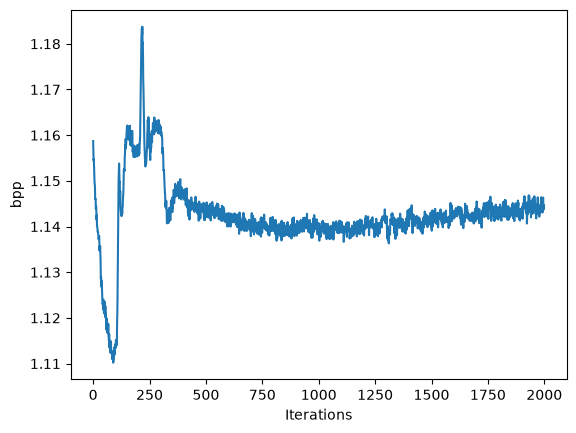

In [23]:
# ADMM
quality_loss_lambda = 1  # hyperparameter
num_iterations = 100
target_psnr = 35  # hyperparameter

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(
    input_tensor, sr_image_tensor_orig, target_psnr,
    quality_loss_lambda, num_iterations, model, model_compression,
    device=device, learningrate=LORA_LR,
    Z_tensor=Z_tensor, T_tensor=T_tensor,
    checkpoint_dir=CKPT_DIR, start_outer=start_outer,
    loss_values=loss_values_hist, bpp_values=bpp_values_hist, psnr_values=psnr_values_hist,
    optimizer_state=optimizer_state,
)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()


In [24]:
sr_image_tensor_orig = sr_image_tensor_orig.detach()  # Detaches it from any computational graph

In [25]:
import pickle

results = {
    "filename": filename,
    "psnr": psnr_values_,
    "loss_values": loss_values_,
    "bpp_values":bpp_values_,
}

results_file = f"result_2x_{filename}.pkl"
with open(results_file, "wb") as f:
    pickle.dump(results, f)
    
    

In [26]:
# Evaluate performance with the resized image
sr_compression_result_spnet_bitmin = eval_perf_compression(model_compression, Z_tensor, ground_truth_tensor)
sr_compression_result_spnet_bitmin

/tmp/ipykernel_1485323/1750059163.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(31.937698, dtype=float32),
 'Bpp': array(1.1435608, dtype=float32),
 'Bpp(fsize)': 1.056060791015625,
 'SSIM': array(0.04979114, dtype=float32),
 'PSNR_cmpref': array(28.458902, dtype=float32),
 'SSI_cmpref': array(0.05618184, dtype=float32)}

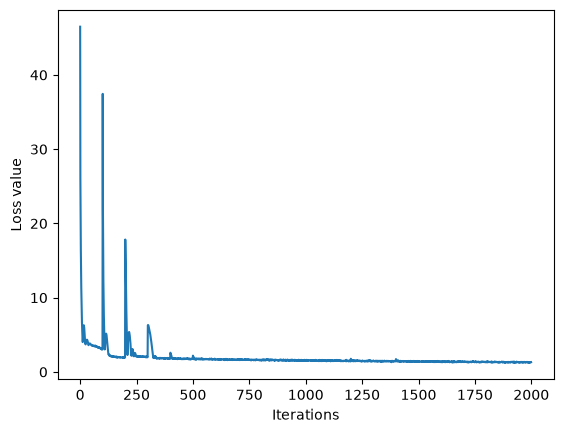

In [27]:
plt.plot(loss_values_)
plt.xlabel("Iterations")
plt.ylabel("Loss value")
plt.show()

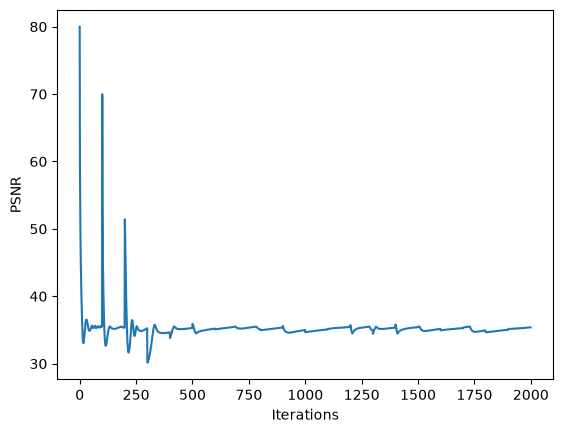

In [28]:
plt.plot(psnr_values_)
plt.xlabel("Iterations")
plt.ylabel("PSNR")
plt.show()

In [29]:
bpp_values_ = np.array(bpp_values_)

np.min(bpp_values_[np.abs(np.array(psnr_values_)-np.float32(target_psnr))<=1e-2])

1.1220499277114868

Outer 0 | Iter 0 | PSNR cmp: 33.81 | BPP: 1.1446 | Loss: 1.3350
Checkpoint saved: outer 1/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 33.80 | BPP: 1.1383 | Loss: 1.1186
Checkpoint saved: outer 2/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 33.74 | BPP: 1.1374 | Loss: 1.1711
Checkpoint saved: outer 3/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0002.pt
Outer 3 | Iter 0 | PSNR cmp: 33.77 | BPP: 1.1343 | Loss: 1.1292
Checkpoint saved: outer 4/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0003.pt
Outer 4 | Iter 0 | PSNR cmp: 33.77 | BPP: 1.1349 | Loss: 1.2601
Checkpoint saved: outer 5/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0004.pt
Outer 5 | Iter 0 | PSNR cmp: 33.76 | BPP: 1.1381 | Loss: 1.1542
Checkpoint saved: outer 6/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/ru

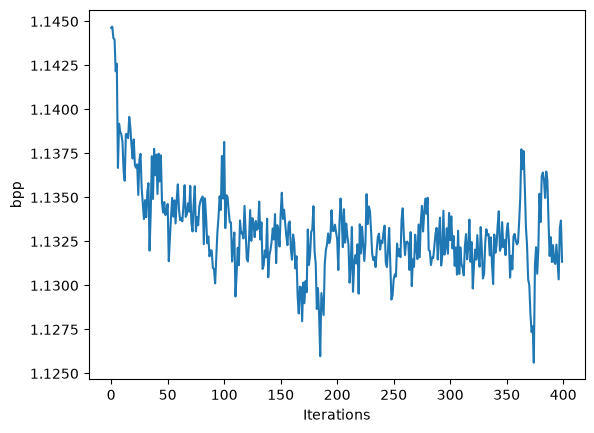

In [30]:
# ADMM
 
quality_loss_lambda = .8
# num_iterations = 100
num_iterations = 20
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = LORA_LR, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()


Outer 0 | Iter 0 | PSNR cmp: 33.84 | BPP: 1.1325 | Loss: 1.6389
Outer 0 | Iter 30 | PSNR cmp: 33.79 | BPP: 1.1310 | Loss: 1.1031
Outer 0 | Iter 60 | PSNR cmp: 33.80 | BPP: 1.1339 | Loss: 1.1027
Outer 0 | Iter 90 | PSNR cmp: 33.80 | BPP: 1.1336 | Loss: 1.1015
Checkpoint saved: outer 1/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 33.88 | BPP: 1.1322 | Loss: 1.1375
Outer 1 | Iter 30 | PSNR cmp: 33.86 | BPP: 1.1331 | Loss: 1.0564
Outer 1 | Iter 60 | PSNR cmp: 33.83 | BPP: 1.1329 | Loss: 1.0775
Outer 1 | Iter 90 | PSNR cmp: 33.78 | BPP: 1.1316 | Loss: 1.1143
Checkpoint saved: outer 2/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 33.87 | BPP: 1.1326 | Loss: 1.2717
Outer 2 | Iter 30 | PSNR cmp: 33.85 | BPP: 1.1328 | Loss: 1.0654
Outer 2 | Iter 60 | PSNR cmp: 33.89 | BPP: 1.1315 | Loss: 1.0237
Outer 2 | Iter 90 | PSNR cmp: 33.89 | BPP: 1.1311 | Loss: 1.0194
Checkpo

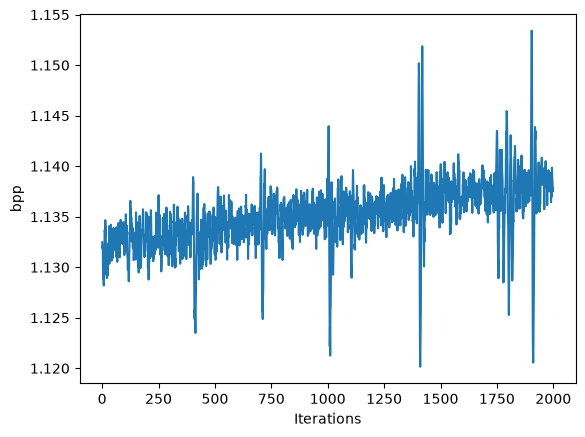

In [31]:
# ADMM
 
quality_loss_lambda = .8
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = LORA_LR, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()


Outer 0 | Iter 0 | PSNR cmp: 34.08 | BPP: 1.1375 | Loss: 0.8959
Outer 0 | Iter 30 | PSNR cmp: 34.10 | BPP: 1.1374 | Loss: 0.8781
Outer 0 | Iter 60 | PSNR cmp: 34.10 | BPP: 1.1408 | Loss: 0.8943
Outer 0 | Iter 90 | PSNR cmp: 34.07 | BPP: 1.1403 | Loss: 0.9243
Checkpoint saved: outer 1/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 34.09 | BPP: 1.1364 | Loss: 0.9564
Outer 1 | Iter 30 | PSNR cmp: 34.11 | BPP: 1.1387 | Loss: 0.8775
Outer 1 | Iter 60 | PSNR cmp: 34.09 | BPP: 1.1375 | Loss: 0.8900
Outer 1 | Iter 90 | PSNR cmp: 34.03 | BPP: 1.1368 | Loss: 0.9345
Checkpoint saved: outer 2/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 34.05 | BPP: 1.1380 | Loss: 0.9185
Outer 2 | Iter 30 | PSNR cmp: 34.12 | BPP: 1.1396 | Loss: 0.8702
Outer 2 | Iter 60 | PSNR cmp: 34.07 | BPP: 1.1401 | Loss: 0.9159
Outer 2 | Iter 90 | PSNR cmp: 34.12 | BPP: 1.1406 | Loss: 0.8714
Checkpo

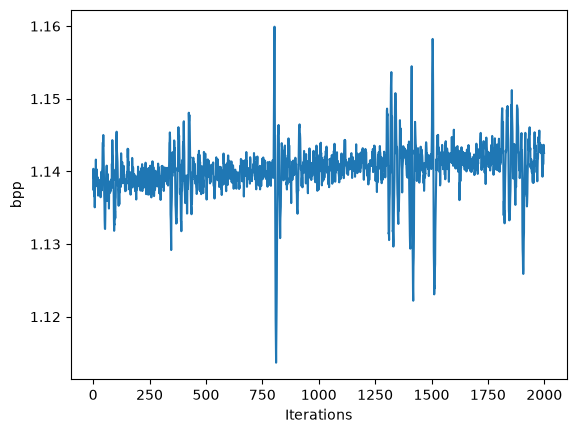

In [32]:
# ADMM
 
quality_loss_lambda = .8
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = LORA_LR, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()


Outer 0 | Iter 0 | PSNR cmp: 34.17 | BPP: 1.1403 | Loss: 0.8275
Outer 0 | Iter 30 | PSNR cmp: 34.10 | BPP: 1.1274 | Loss: 0.7598
Outer 0 | Iter 60 | PSNR cmp: 34.08 | BPP: 1.1246 | Loss: 0.7650
Outer 0 | Iter 90 | PSNR cmp: 34.05 | BPP: 1.1233 | Loss: 0.7734
Checkpoint saved: outer 1/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 34.12 | BPP: 1.1222 | Loss: 0.8585
Outer 1 | Iter 30 | PSNR cmp: 34.09 | BPP: 1.1198 | Loss: 0.7391
Outer 1 | Iter 60 | PSNR cmp: 34.06 | BPP: 1.1212 | Loss: 0.7614
Outer 1 | Iter 90 | PSNR cmp: 34.07 | BPP: 1.1233 | Loss: 0.7622
Checkpoint saved: outer 2/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 34.09 | BPP: 1.1199 | Loss: 0.7397
Outer 2 | Iter 30 | PSNR cmp: 34.03 | BPP: 1.1200 | Loss: 0.7710
Outer 2 | Iter 60 | PSNR cmp: 34.09 | BPP: 1.1216 | Loss: 0.7461
Outer 2 | Iter 90 | PSNR cmp: 34.06 | BPP: 1.1229 | Loss: 0.7687
Checkpo

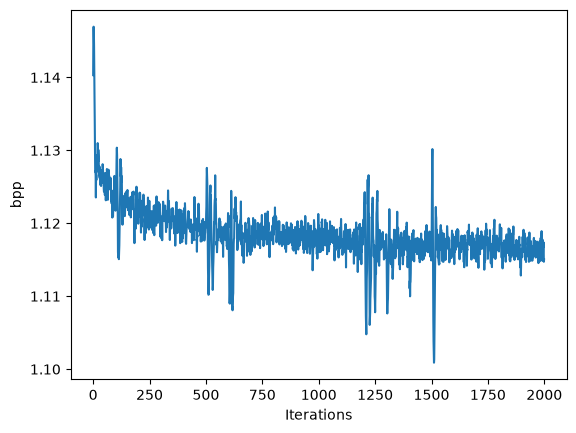

In [33]:
# ADMM
 
quality_loss_lambda = .6
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = LORA_LR, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()


In [34]:
# Evaluate performance with the resized image
sr_compression_result_spnet_bitmin = eval_perf_compression(model_compression, Z_tensor, ground_truth_tensor)
sr_compression_result_spnet_bitmin

/tmp/ipykernel_1485323/1750059163.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(32.522537, dtype=float32),
 'Bpp': array(1.116149, dtype=float32),
 'Bpp(fsize)': 1.024444580078125,
 'SSIM': array(0.03311159, dtype=float32),
 'PSNR_cmpref': array(28.515093, dtype=float32),
 'SSI_cmpref': array(0.05667027, dtype=float32)}

Outer 0 | Iter 0 | PSNR cmp: 34.11 | BPP: 1.1164 | Loss: 0.7132
Outer 0 | Iter 30 | PSNR cmp: 34.09 | BPP: 1.1164 | Loss: 0.7260
Outer 0 | Iter 60 | PSNR cmp: 34.10 | BPP: 1.1155 | Loss: 0.7141
Outer 0 | Iter 90 | PSNR cmp: 34.03 | BPP: 1.1177 | Loss: 0.7630
Checkpoint saved: outer 1/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 34.07 | BPP: 1.1164 | Loss: 0.7364
Outer 1 | Iter 30 | PSNR cmp: 34.08 | BPP: 1.1165 | Loss: 0.7292
Outer 1 | Iter 60 | PSNR cmp: 34.08 | BPP: 1.1169 | Loss: 0.7333
Outer 1 | Iter 90 | PSNR cmp: 34.11 | BPP: 1.1167 | Loss: 0.7154
Checkpoint saved: outer 2/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 34.12 | BPP: 1.1176 | Loss: 0.8350
Outer 2 | Iter 30 | PSNR cmp: 34.07 | BPP: 1.1159 | Loss: 0.7394
Outer 2 | Iter 60 | PSNR cmp: 34.04 | BPP: 1.1141 | Loss: 0.7429
Outer 2 | Iter 90 | PSNR cmp: 34.06 | BPP: 1.1155 | Loss: 0.7412
Checkpo

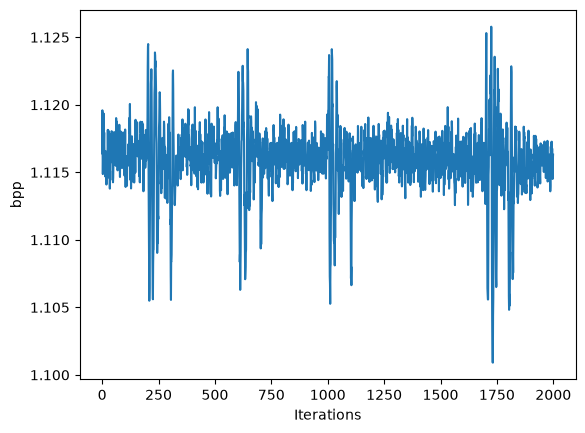

In [35]:
# ADMM
 
quality_loss_lambda = .6
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = LORA_LR, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()


In [36]:
sr_compression_result_spnet_bitmin = eval_perf_compression(model_compression, Z_tensor, ground_truth_tensor)
sr_compression_result_spnet_bitmin

/tmp/ipykernel_1485323/1750059163.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(32.569, dtype=float32),
 'Bpp': array(1.1162736, dtype=float32),
 'Bpp(fsize)': 1.022857666015625,
 'SSIM': array(0.03216056, dtype=float32),
 'PSNR_cmpref': array(28.50517, dtype=float32),
 'SSI_cmpref': array(0.05669623, dtype=float32)}

Outer 0 | Iter 0 | PSNR cmp: 34.07 | BPP: 1.1141 | Loss: 0.6834
Outer 0 | Iter 30 | PSNR cmp: 34.01 | BPP: 1.1041 | Loss: 0.6757
Outer 0 | Iter 60 | PSNR cmp: 34.01 | BPP: 1.1037 | Loss: 0.6750
Outer 0 | Iter 90 | PSNR cmp: 34.01 | BPP: 1.1006 | Loss: 0.6617
Checkpoint saved: outer 1/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 34.00 | BPP: 1.1014 | Loss: 0.6683
Outer 1 | Iter 30 | PSNR cmp: 34.06 | BPP: 1.1039 | Loss: 0.6503
Outer 1 | Iter 60 | PSNR cmp: 34.00 | BPP: 1.1019 | Loss: 0.6691
Outer 1 | Iter 90 | PSNR cmp: 34.02 | BPP: 1.0997 | Loss: 0.6524
Checkpoint saved: outer 2/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 34.02 | BPP: 1.1008 | Loss: 0.6578
Outer 2 | Iter 30 | PSNR cmp: 33.97 | BPP: 1.0955 | Loss: 0.6590
Outer 2 | Iter 60 | PSNR cmp: 33.95 | BPP: 1.0977 | Loss: 0.6784
Outer 2 | Iter 90 | PSNR cmp: 33.99 | BPP: 1.0967 | Loss: 0.6581
Checkpo

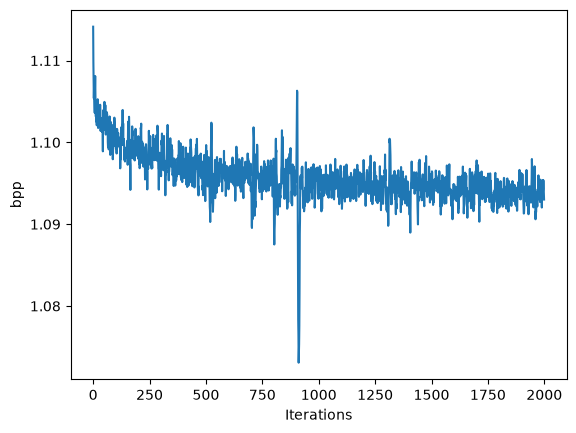

In [37]:
# ADMM
 
quality_loss_lambda = .5
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = LORA_LR, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()


Outer 0 | Iter 0 | PSNR cmp: 34.01 | BPP: 1.0934 | Loss: 0.4853
Outer 0 | Iter 30 | PSNR cmp: 32.65 | BPP: 0.9965 | Loss: 0.3549
Outer 0 | Iter 60 | PSNR cmp: 32.44 | BPP: 0.9767 | Loss: 0.3101
Outer 0 | Iter 90 | PSNR cmp: 32.23 | BPP: 0.9601 | Loss: 0.2778
Checkpoint saved: outer 1/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 32.18 | BPP: 0.9622 | Loss: 0.3113
Outer 1 | Iter 30 | PSNR cmp: 31.76 | BPP: 0.9337 | Loss: 0.2498
Outer 1 | Iter 60 | PSNR cmp: 31.71 | BPP: 0.9273 | Loss: 0.2308
Outer 1 | Iter 90 | PSNR cmp: 31.55 | BPP: 0.9193 | Loss: 0.2246
Checkpoint saved: outer 2/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 31.51 | BPP: 0.9156 | Loss: 0.2961
Outer 2 | Iter 30 | PSNR cmp: 31.63 | BPP: 0.9223 | Loss: 0.2233
Outer 2 | Iter 60 | PSNR cmp: 31.65 | BPP: 0.9246 | Loss: 0.2289
Outer 2 | Iter 90 | PSNR cmp: 31.55 | BPP: 0.9159 | Loss: 0.2114
Checkpo

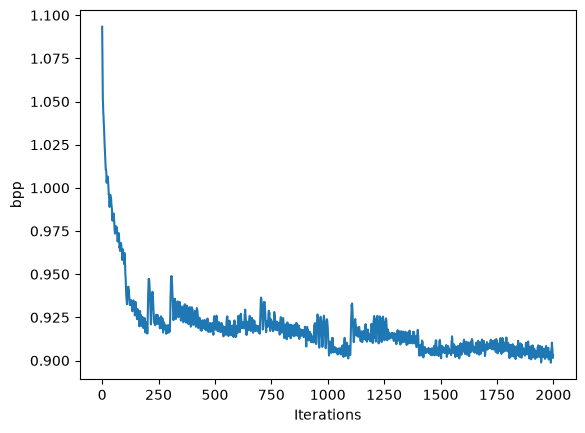

In [38]:
# ADMM
 
quality_loss_lambda = .2
num_iterations = 100
target_psnr = 35

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = LORA_LR, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()


In [39]:
sr_compression_result_spnet_bitmin = eval_perf_compression(model_compression, Z_tensor, ground_truth_tensor)
sr_compression_result_spnet_bitmin

/tmp/ipykernel_1485323/1750059163.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(35.35575, dtype=float32),
 'Bpp': array(0.9046343, dtype=float32),
 'Bpp(fsize)': 0.802276611328125,
 'SSIM': array(0.01923197, dtype=float32),
 'PSNR_cmpref': array(27.723522, dtype=float32),
 'SSI_cmpref': array(0.0727986, dtype=float32)}

Outer 0 | Iter 0 | PSNR cmp: 31.53 | BPP: 0.9038 | Loss: 1.4943
Outer 0 | Iter 30 | PSNR cmp: 31.27 | BPP: 0.9116 | Loss: -0.1715
Outer 0 | Iter 60 | PSNR cmp: 31.55 | BPP: 0.9153 | Loss: -0.3846
Outer 0 | Iter 90 | PSNR cmp: 31.49 | BPP: 0.9071 | Loss: -0.4101
Checkpoint saved: outer 1/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0000.pt
Outer 1 | Iter 0 | PSNR cmp: 31.57 | BPP: 0.9110 | Loss: 3.8044
Outer 1 | Iter 30 | PSNR cmp: 31.58 | BPP: 0.9377 | Loss: -0.2795
Outer 1 | Iter 60 | PSNR cmp: 31.59 | BPP: 0.9271 | Loss: -0.3289
Outer 1 | Iter 90 | PSNR cmp: 31.50 | BPP: 0.9197 | Loss: -0.3593
Checkpoint saved: outer 2/20 -> /gpfs/gpfs0/timofey.glukhikh/Science_Phan/runs/0008_nina_lora/outer_0001.pt
Outer 2 | Iter 0 | PSNR cmp: 31.46 | BPP: 0.9164 | Loss: -0.1215
Outer 2 | Iter 30 | PSNR cmp: 31.55 | BPP: 0.9128 | Loss: -0.3963
Outer 2 | Iter 60 | PSNR cmp: 31.51 | BPP: 0.9120 | Loss: -0.3999
Outer 2 | Iter 90 | PSNR cmp: 31.50 | BPP: 0.9098 | Loss: -0.41

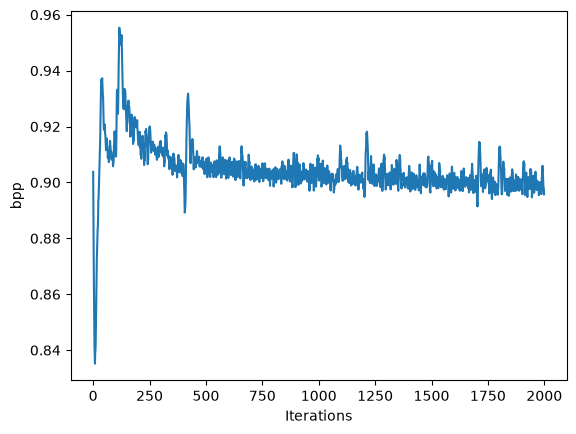

In [40]:
# ADMM
 
quality_loss_lambda = 1
num_iterations = 100
target_psnr = 32

model, Z_tensor, T_tensor, loss_values, bpp_values, psnr_values = minbitrate_superresolution(input_tensor,sr_image_tensor_orig, target_psnr,
                           quality_loss_lambda, num_iterations, model, model_compression, device=device, learningrate = LORA_LR, Z_tensor=Z_tensor, T_tensor=T_tensor,
                           checkpoint_dir=CKPT_DIR)
loss_values_, bpp_values_, psnr_values_ = loss_values, bpp_values, psnr_values
plt.plot(bpp_values_)
plt.xlabel("Iterations")
plt.ylabel("bpp")
plt.show()


In [41]:
sr_compression_result_spnet_bitmin = eval_perf_compression(model_compression, Z_tensor, ground_truth_tensor)
sr_compression_result_spnet_bitmin

/tmp/ipykernel_1485323/1750059163.py:33: UserWarning: Inference on GPU is not recommended for the autoregressive models (the entropy coder is run sequentially on CPU).
  sr_output = model_compression.compress(sr_image_tensor)


{'PSNR': array(33.019096, dtype=float32),
 'Bpp': array(0.8976855, dtype=float32),
 'Bpp(fsize)': 0.793609619140625,
 'SSIM': array(0.04425392, dtype=float32),
 'PSNR_cmpref': array(27.71056, dtype=float32),
 'SSI_cmpref': array(0.07348145, dtype=float32)}

[{'PSNR': array(33.162262, dtype=float32),
  'Bpp': array(1.2745446, dtype=float32),
  'Bpp(fsize)': 1.206451416015625,
  'SSIM': array(0.02922462, dtype=float32),
  'PSNR_cmpref': array(25.464651, dtype=float32),
  'SSI_cmpref': array(0.08608275, dtype=float32)},
 {'PSNR': array(36.905064, dtype=float32),
  'Bpp': array(0.77758557, dtype=float32),
  'Bpp(fsize)': 0.666900634765625,
  'SSIM': array(0.01620233, dtype=float32),
  'PSNR_cmpref': array(25.581451, dtype=float32),
  'SSI_cmpref': array(0.09474851, dtype=float32)},
 {'PSNR': array(35.746845, dtype=float32),
  'Bpp': array(0.89696914, dtype=float32),
  'Bpp(fsize)': 0.790802001953125,
  'SSIM': array(0.01841858, dtype=float32),
  'PSNR_cmpref': array(26.59946, dtype=float32),
  'SSI_cmpref': array(0.07771316, dtype=float32)}]

more lambdas with 32 difference pnsr